In [1]:
!pip install -U pandas numpy scikit-learn pyarrow joblib

In [2]:
import os, glob
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

import joblib

In [3]:
# --- DATA PATHS (EDIT THESE) ---
TRAIN_A_DIR = r"C:\physionet\challenge2019\training\training_setA"
TRAIN_B_DIR = r"C:\physionet\challenge2019\training\training_setB"

# --- OUTPUTS ---
OUT_DATASETS = r"outputs\datasets"
OUT_MODELS   = r"outputs\models"
OUT_REPORTS  = r"outputs\reports"

os.makedirs(OUT_DATASETS, exist_ok=True)
os.makedirs(OUT_MODELS, exist_ok=True)
os.makedirs(OUT_REPORTS, exist_ok=True)

# --- TASK SETTINGS ---
HORIZON_HOURS = 24          # predict AKI onset within next 24h
MIN_HISTORY_HOURS = 6       # start learning after ICU hour >= 6
WINDOWS = [1, 3, 6, 12, 24, 48]
RANDOM_SEED = 42

# Start small, then scale: 50 -> 300 -> 2000 -> None (full)
MAX_PATIENTS = None

In [4]:
filesA = sorted(glob.glob(os.path.join(TRAIN_A_DIR, "*.psv")))
filesB = sorted(glob.glob(os.path.join(TRAIN_B_DIR, "*.psv")))
files = filesA + filesB

print("Found A:", len(filesA), "B:", len(filesB), "Total:", len(files))
print("Example:", files[0] if files else "NO FILES - fix paths")

Found A: 20336 B: 15984 Total: 36320
Example: C:\physionet\challenge2019\training\training_setA\p000001.psv


In [5]:
BASE_COLS = [
    "HR","O2Sat","Temp","SBP","MAP","DBP","Resp","EtCO2",
    "BUN","Creatinine","Glucose","Lactate","WBC","Platelets","Hgb","Hct",
    "Potassium","Chloride","Calcium","Magnesium","Phosphate",
    "Bilirubin_total","AST",
    "Age","Gender","HospAdmTime","ICULOS"
]

In [6]:
def label_aki_kdigo_rolling48h(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "ICULOS" not in df.columns:
        df["ICULOS"] = np.arange(1, len(df)+1)

    df["ICULOS"] = pd.to_numeric(df["ICULOS"], errors="coerce")
    df["Creatinine"] = pd.to_numeric(df.get("Creatinine", np.nan), errors="coerce")

    cr = df["Creatinine"]

    baseline_global = cr.dropna().iloc[0] if cr.dropna().shape[0] else np.nan
    roll_min_48 = cr.rolling(window=48, min_periods=1).min()

    cond_48 = (cr - roll_min_48) >= 0.3
    cond_15 = cr >= (1.5 * baseline_global) if not np.isnan(baseline_global) else False

    df["AKI_event"] = (cond_48 | cond_15).fillna(False).astype(int)
    df["AKI_onset"] = (df["AKI_event"].diff().fillna(df["AKI_event"]) == 1).astype(int)
    return df


def add_future_target(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    df = df.copy()
    onset = df["AKI_onset"].astype(int).values

    y = np.zeros(len(df), dtype=int)
    for t in range(len(df)):
        future = onset[t+1 : min(len(df), t + horizon + 1)]
        y[t] = 1 if future.sum() > 0 else 0

    df["AKI_within_horizon"] = y
    return df

In [7]:
def make_features_fast(df: pd.DataFrame, windows=WINDOWS) -> pd.DataFrame:
    df = df.copy()

    # Ensure numeric cols exist
    for c in BASE_COLS:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Missing indicators (useful signal in ICU data)
    miss = {f"{c}_isna": df[c].isna().astype(int) for c in BASE_COLS}

    # Forward fill for roll/delta features
    df_ff = df[BASE_COLS].ffill()

    feats = {}
    for c in BASE_COLS:
        s = df_ff[c]
        for k in windows:
            feats[f"{c}_delta_{k}h"] = s - s.shift(k)
            roll = s.rolling(k, min_periods=1)
            feats[f"{c}_mean_{k}h"] = roll.mean()
            feats[f"{c}_min_{k}h"]  = roll.min()
            feats[f"{c}_max_{k}h"]  = roll.max()

    # Kidney-specific extras
    cr = df_ff["Creatinine"]
    feats["cr_rollmin_48h"] = cr.rolling(48, min_periods=1).min()
    feats["cr_above_rollmin_48h"] = cr - feats["cr_rollmin_48h"]
    feats["cr_slope_6h"] = (cr - cr.shift(6)) / 6.0
    feats["cr_slope_12h"] = (cr - cr.shift(12)) / 12.0

    feat_df = pd.DataFrame({**miss, **feats})
    return pd.concat([df, feat_df], axis=1)

In [8]:
def process_patient(path: str) -> pd.DataFrame:
    pid = os.path.splitext(os.path.basename(path))[0]
    df = pd.read_csv(path, sep="|")
    df["patient_id"] = pid

    if "ICULOS" not in df.columns:
        df["ICULOS"] = np.arange(1, len(df)+1)

    df = label_aki_kdigo_rolling48h(df)
    df = add_future_target(df, horizon=HORIZON_HOURS)
    df = make_features_fast(df, windows=WINDOWS)

    df["ICULOS"] = pd.to_numeric(df["ICULOS"], errors="coerce")
    df = df[df["ICULOS"] >= MIN_HISTORY_HOURS].reset_index(drop=True)
    return df


def build_dataset(file_list, max_patients=300) -> pd.DataFrame:
    out = []
    use_list = file_list if (max_patients is None) else file_list[:max_patients]

    for i, p in enumerate(use_list, 1):
        try:
            out.append(process_patient(p))
        except Exception as e:
            print("[SKIP]", os.path.basename(p), "->", e)

        if i % 50 == 0:
            print("Processed", i, "/", len(use_list))

    ds = pd.concat(out, ignore_index=True)
    return ds


dataset = build_dataset(files, max_patients=MAX_PATIENTS)

print("Dataset shape:", dataset.shape)
print("Unique patients:", dataset["patient_id"].nunique())
print("Label counts:\n", dataset["AKI_within_horizon"].value_counts())
print("Prevalence:", float(dataset["AKI_within_horizon"].mean()))

Processed 50 / 36320
Processed 100 / 36320
Processed 150 / 36320
Processed 200 / 36320
Processed 250 / 36320
Processed 300 / 36320
Processed 350 / 36320
Processed 400 / 36320
Processed 450 / 36320
Processed 500 / 36320
Processed 550 / 36320
Processed 600 / 36320
Processed 650 / 36320
Processed 700 / 36320
Processed 750 / 36320
Processed 800 / 36320
Processed 850 / 36320
Processed 900 / 36320
Processed 950 / 36320
Processed 1000 / 36320
Processed 1050 / 36320
Processed 1100 / 36320
Processed 1150 / 36320
Processed 1200 / 36320
Processed 1250 / 36320
Processed 1300 / 36320
Processed 1350 / 36320
Processed 1400 / 36320
Processed 1450 / 36320
Processed 1500 / 36320
Processed 1550 / 36320
Processed 1600 / 36320
Processed 1650 / 36320
Processed 1700 / 36320
Processed 1750 / 36320
Processed 1800 / 36320
Processed 1850 / 36320
Processed 1900 / 36320
Processed 1950 / 36320
Processed 2000 / 36320
Processed 2050 / 36320
Processed 2100 / 36320
Processed 2150 / 36320
Processed 2200 / 36320
Processe

In [9]:
DROP_COLS = {"AKI_event", "AKI_onset", "AKI_within_horizon", "patient_id", "SepsisLabel"}
feature_cols = [c for c in dataset.columns if c not in DROP_COLS]

X = dataset[feature_cols]
y = dataset["AKI_within_horizon"].astype(int)

# Drop all-NaN columns (EtCO2 in many subsets, etc.)
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print("Dropping all-NaN feature columns:", len(all_nan_cols))
    X = X.drop(columns=all_nan_cols)

print("Final feature count:", X.shape[1])

Final feature count: 719


In [10]:
patient_labels = dataset.groupby("patient_id")["AKI_within_horizon"].max()
patients = patient_labels.index.values
labels = patient_labels.values

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=labels
)

train_idx = dataset["patient_id"].isin(train_patients)
test_idx  = dataset["patient_id"].isin(test_patients)

X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx].values
y_test  = y.loc[test_idx].values

print("Train positives:", int(y_train.sum()), "/", len(y_train))
print("Test positives :", int(y_test.sum()), "/", len(y_test))

Train positives: 90520 / 986112
Test positives : 23099 / 248517


In [11]:
logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

logreg.fit(X_train, y_train)
p_lr = logreg.predict_proba(X_test)[:, 1]

print("LogReg AUROC:", roc_auc_score(y_test, p_lr))
print("LogReg AUPRC:", average_precision_score(y_test, p_lr))
print("LogReg Brier:", brier_score_loss(y_test, p_lr))

C:\Users\Admin\anaconda3\envs\aki_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg AUROC: 0.8216271206139587
LogReg AUPRC: 0.3483200243699641
LogReg Brier: 0.07224324933635233


In [12]:
hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=400,
    random_state=RANDOM_SEED
)

hgb.fit(X_train, y_train)
p_hgb = hgb.predict_proba(X_test)[:, 1]

print("HGB AUROC:", roc_auc_score(y_test, p_hgb))
print("HGB AUPRC:", average_precision_score(y_test, p_hgb))
print("HGB Brier:", brier_score_loss(y_test, p_hgb))

HGB AUROC: 0.8728291419472257
HGB AUPRC: 0.48937146041663804
HGB Brier: 0.062361392705054544


In [13]:
# Save dataset
ds_path = os.path.join(OUT_DATASETS, f"aki_h{HORIZON_HOURS}_n{MAX_PATIENTS}.parquet")
dataset.to_parquet(ds_path, index=False)
print("Saved dataset:", ds_path)

# Save models with feature list
joblib.dump({"model": logreg, "features": X.columns.tolist()}, os.path.join(OUT_MODELS, "logreg_aki.joblib"))
joblib.dump({"model": hgb, "features": X.columns.tolist()}, os.path.join(OUT_MODELS, "hgb_aki.joblib"))
print("Saved models to:", OUT_MODELS)

# Save metrics
metrics = pd.DataFrame([
    {"model":"logreg", "AUROC": roc_auc_score(y_test, p_lr), "AUPRC": average_precision_score(y_test, p_lr), "Brier": brier_score_loss(y_test, p_lr)},
    {"model":"hgb",    "AUROC": roc_auc_score(y_test, p_hgb), "AUPRC": average_precision_score(y_test, p_hgb), "Brier": brier_score_loss(y_test, p_hgb)},
])

rep_path = os.path.join(OUT_REPORTS, f"metrics_h{HORIZON_HOURS}_n{MAX_PATIENTS}.csv")
metrics.to_csv(rep_path, index=False)
print("Saved metrics:", rep_path)

metrics

Saved dataset: outputs\datasets\aki_h24_nNone.parquet
Saved models to: outputs\models
Saved metrics: outputs\reports\metrics_h24_nNone.csv


,model,AUROC,AUPRC,Brier
0,logreg,0.821627,0.348320,0.072243
1,hgb,0.872829,0.489371,0.062361


In [14]:
probs = p_hgb  # use best model
bands = pd.cut(probs, bins=[-1, 0.05, 0.20, 1.01], labels=["LOW", "MED", "HIGH"])

tmp = pd.DataFrame({"p": probs, "y": y_test, "band": bands})
print("Counts per band:\n", tmp["band"].value_counts())
print("\nAKI rate per band:\n", tmp.groupby("band")["y"].mean())

Counts per band:
 band
LOW     161105
MED      54813
HIGH     32599
Name: count, dtype: int64

AKI rate per band:
 band
LOW     0.018572
MED     0.113696
HIGH    0.425627
Name: y, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_11556\1399620815.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("\nAKI rate per band:\n", tmp.groupby("band")["y"].mean())


In [15]:
print("Patients:", dataset["patient_id"].nunique())
print(dataset["AKI_within_horizon"].value_counts(normalize=True))

Patients: 36320
AKI_within_horizon
0    0.907973
1    0.092027
Name: proportion, dtype: float64


In [6]:
import pandas as pd
import joblib

# load dataset
dataset = pd.read_parquet("outputs/datasets/aki_h24_nNone.parquet")

# load model
model_data = joblib.load("outputs/models/hgb_aki.joblib")
hgb = model_data["model"]
features = model_data["features"]

In [7]:
X = dataset[features]
y = dataset["AKI_within_horizon"].astype(int)

In [8]:
from sklearn.model_selection import train_test_split

patient_labels = dataset.groupby("patient_id")["AKI_within_horizon"].max()

patients = patient_labels.index.values
labels = patient_labels.values

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_idx = dataset["patient_id"].isin(train_patients)
test_idx  = dataset["patient_id"].isin(test_patients)

X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]

y_train = y.loc[train_idx].values
y_test  = y.loc[test_idx].values

print("X_test shape:", X_test.shape)

X_test shape: (248517, 719)


In [9]:
from sklearn.inspection import permutation_importance
import numpy as np

sample_n = min(5000, len(X_test))

sample_idx = np.random.RandomState(42).choice(
    len(X_test),
    size=sample_n,
    replace=False
)

X_imp = X_test.iloc[sample_idx]
y_imp = y_test[sample_idx]

result = permutation_importance(
    hgb,
    X_imp,
    y_imp,
    n_repeats=3,
    random_state=42,
    n_jobs=1
)

importances = pd.Series(
    result.importances_mean,
    index=X_imp.columns
).sort_values(ascending=False)

print(importances.head(20))

cr_above_rollmin_48h    0.013267
BUN_mean_1h             0.001267
Creatinine_min_48h      0.001200
Lactate_max_24h         0.001133
Glucose_min_24h         0.001067
Creatinine_max_3h       0.001067
Creatinine_delta_12h    0.000933
ICULOS                  0.000933
Lactate_max_12h         0.000933
Calcium_mean_24h        0.000867
ICULOS_min_48h          0.000800
Creatinine_mean_1h      0.000800
SBP_max_48h             0.000800
Creatinine_max_12h      0.000800
SBP                     0.000800
HR_max_48h              0.000733
BUN_min_48h             0.000733
DBP_max_48h             0.000733
Platelets_mean_1h       0.000667
DBP_mean_48h            0.000667
dtype: float64


In [10]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 4.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.6 MB 4.1 MB/s eta 0:00:03
   ------ --------------------------------- 2.1/12.6 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 3.4/12.6 MB 5.7 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/12.6 MB 5.9 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.6 MB 6.3 MB/s eta 0:00:01
   ------------------------ --------------- 7.6/12.6 MB 6.3 MB/s eta 0:00:01
   ---------------------------- ----------- 8.9/12.6 MB 6.4 MB/s eta 0:00:01
   -------------------------------- ------- 10.2/12.6 MB 6.3 MB/s eta 0:00:01
   ----------------------------------- ---- 11.0/12.6 MB 6.1 MB/s eta 0:00:01
   -------------------------------------- - 12.1/12.6 MB 5.9 MB/s eta 0:00:01
   ---

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.8.0 which is incompatible.
streamlit 1.45.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.1 which is incompatible.


In [13]:
import sys
!{sys.executable} -m pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 3.6 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.7 MB 4.8 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.7 MB 4.7 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.7 MB 4.2 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.7 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 2.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 2.8 MB/s eta 0:00:14
   - -------------------------------------- 1.3/38.1 MB 3.5 MB/s eta 0:00:11
   -- ------------------------------------- 2.4/38.1 MB 4.1 MB/s eta

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [14]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.49.1


In [15]:
import pandas as pd
import numpy as np
import joblib
import shap

from sklearn.model_selection import train_test_split

In [16]:
dataset = pd.read_parquet("outputs/datasets/aki_h24_nNone.parquet")

model_data = joblib.load("outputs/models/hgb_aki.joblib")
hgb = model_data["model"]
features = model_data["features"]

print("Dataset shape:", dataset.shape)
print("Number of features:", len(features))

Dataset shape: (1234629, 724)
Number of features: 719


In [17]:
X = dataset[features]
y = dataset["AKI_within_horizon"].astype(int)

In [18]:
patient_labels = dataset.groupby("patient_id")["AKI_within_horizon"].max()

patients = patient_labels.index.values
labels = patient_labels.values

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_idx = dataset["patient_id"].isin(train_patients)
test_idx  = dataset["patient_id"].isin(test_patients)

X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]

y_train = y.loc[train_idx].values
y_test  = y.loc[test_idx].values

print("X_test shape:", X_test.shape)
print("Test prevalence:", y_test.mean())

X_test shape: (248517, 719)
Test prevalence: 0.09294736376183521


In [19]:
sample_n = min(1000, len(X_test))

sample_idx = np.random.RandomState(42).choice(
    len(X_test),
    size=sample_n,
    replace=False
)

X_shap = X_test.iloc[sample_idx].copy()
y_shap = y_test[sample_idx]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (1000, 719)


In [21]:
explainer = shap.Explainer(hgb, X_shap)

shap_values = explainer(
    X_shap,
    check_additivity=False
)

In [23]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 4.8 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.1 MB 4.4 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.1 MB 4.1 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 3.9 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 3.8 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 4.0 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 4.0 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 4.0 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 4.2 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [24]:
import matplotlib.pyplot as plt

In [27]:
import importlib
import shap

importlib.reload(shap)

<module 'shap' from 'C:\\Users\\Admin\\anaconda3\\envs\\aki_env\\lib\\site-packages\\shap\\__init__.py'>

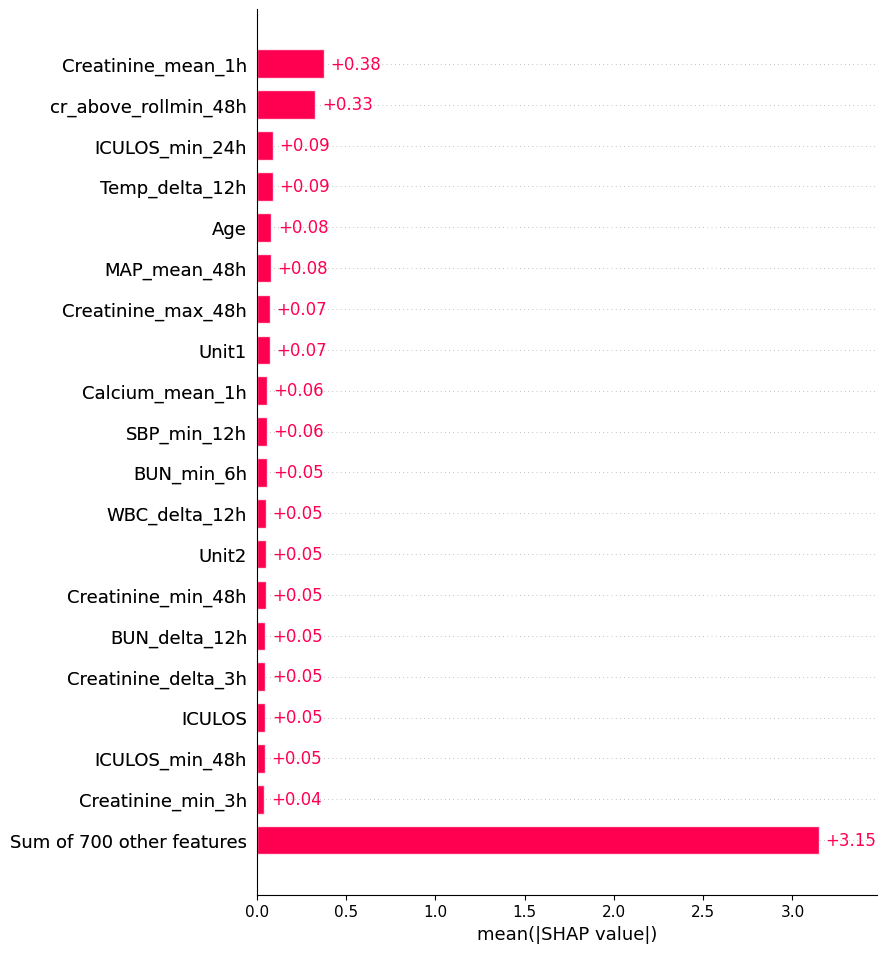

In [29]:
shap.plots.bar(shap_values, max_display=20)

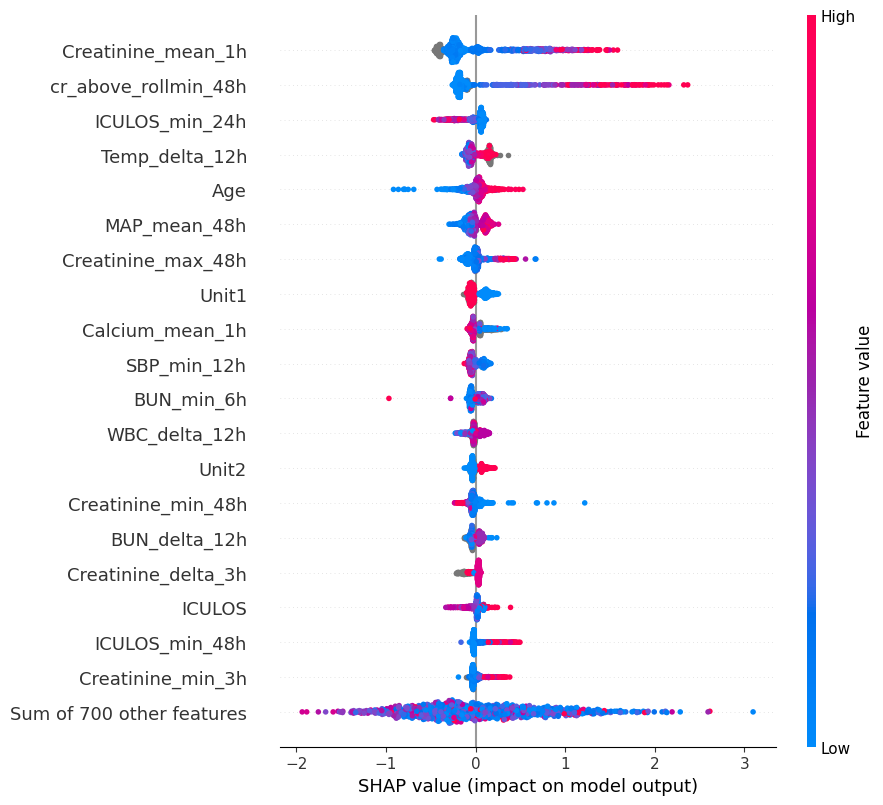

In [30]:
shap.plots.beeswarm(shap_values, max_display=20)

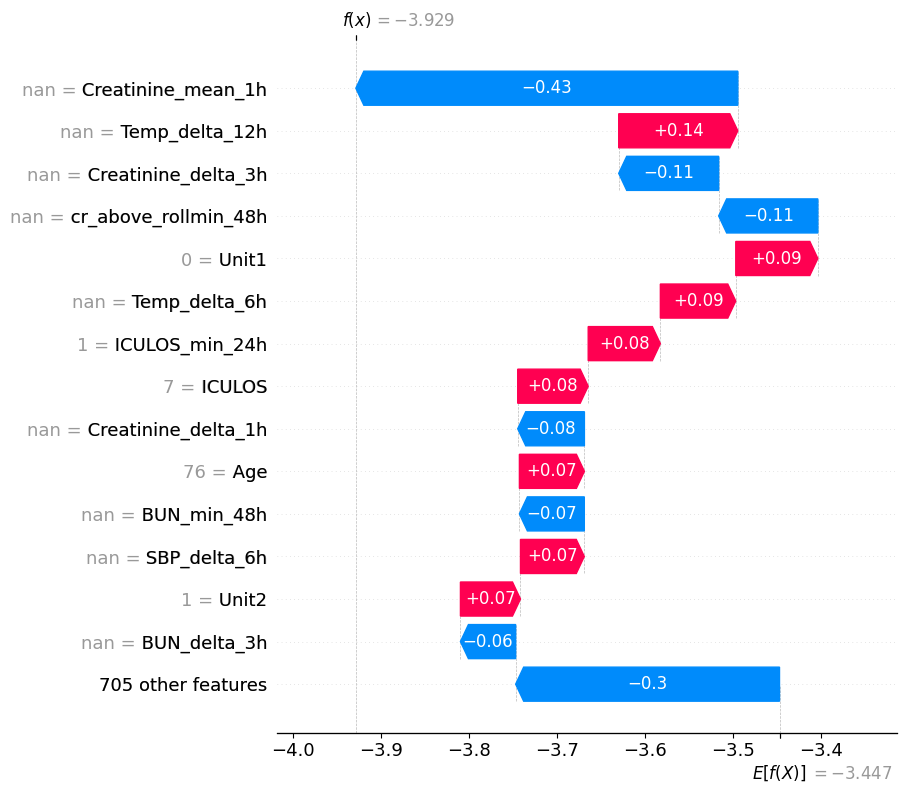

In [31]:
shap.plots.waterfall(shap_values[0], max_display=15)